In [1]:
import os

import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import scanpy as sc
from scipy import stats
from scipy import sparse
import statsmodels.formula.api as smf

import cellspec as spc

%matplotlib inline

In [2]:
import sys

sys.path.append("../scripts/utils")

from barcode_annotation import annotate_barcodes

In [3]:
colors = [
    '#FF1B5E',  # coral
    '#FFDB57',  # yellow
    '#438CFD',  # blue
    '#FF8C00',  # orange
    '#80F15E',  # lime green
    '#03FFFF',  # cyan
    '#5941A9',  # purple
    '#E980FC',  # magenta
    '#1A1A2E',  # navy
    '#F5F0FF',  # lavender white
    '#C17F3E',  # amber brown
]

In [4]:
# sns.set_style("white", {"axes.facecolor": (0, 0, 0, 0)}) 
# plt.style.use("dark_background")

In [5]:
import matplotlib.font_manager as fm
import os, glob


fm._load_fontmanager(try_read_cache=False)
# Register TeX Gyre Heros if present
for f in glob.glob(os.path.expanduser("~/.local/share/fonts/texgyreheros*.otf")):
    fm.fontManager.addfont(f)

In [6]:
mpl.rcParams.update({
    # Font
    "font.family": "sans-serif",
    "font.sans-serif": ["TeX Gyre Heros"],
    "font.size": 12,

    "axes.linewidth": 2.5,
    # Tick marks
    "xtick.major.width": 2.5,
    "ytick.major.width": 2.5,
    "xtick.minor.width": 2.0,
    "ytick.minor.width": 2.0,

    # Tick direction (outward is common in publications)
    "xtick.direction": "out",
    "ytick.direction": "out",
})

# Exp5

In [10]:
L4_exp5 = pd.read_csv('/home/dmullane/working/Dustin/20260531_L4_exp5_test/results/260601_VH00738_413_AAJ7FWGM5/sc_qc_metrics.csv', index_col=0)
L4_exp5['experiment']='5'

,total_reads,aligned_reads,pct_aligned,mean_read_length,mean_insert_size,read_duplicates,pct_duplicates,exonic_reads,exonic_enrichment,splice_reads,pct_1x,pct_5x,pct_10x,mean_coverage,median_coverage,gini
barcode,,,,,,,,,,,,,,,,
A10_A7_A4_B2_20260531_L4_exp5_test,1734,1150,0.663206,119,314.8,104,0.180870,48,0.041739,8,0.000118,0.000028,0.000023,0.000838,0,0.999927
A10_A7_A5_A2_20260531_L4_exp5_test,40,28,0.700000,117,220.7,5,0.357143,0,0.000000,0,0.000014,0.000000,0.000000,0.000016,0,0.999933
A10_A7_A5_G1_20260531_L4_exp5_test,72,54,0.750000,117,200.5,5,0.185185,19,0.351852,0,0.000038,0.000000,0.000000,0.000042,0,0.999867
A10_A7_A6_A1_20260531_L4_exp5_test,146,112,0.767123,119,192.7,12,0.214286,73,0.651786,0,0.000057,0.000000,0.000000,0.000078,0,0.999903
A10_A7_A6_D2_20260531_L4_exp5_test,3212,452,0.140722,118,279.8,35,0.154867,260,0.575221,4,0.000188,0.000004,0.000000,0.000320,0,0.999710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H12_H9_G5_A3_20260531_L4_exp5_test,2710,2232,0.823616,120,194.1,178,0.159498,1185,0.530914,9,0.000500,0.000117,0.000031,0.001659,0,0.999624
H12_H9_G6_D1_20260531_L4_exp5_test,6246,5020,0.803714,119,200.7,435,0.173307,2377,0.473506,20,0.000236,0.000090,0.000053,0.003679,0,0.999923
H12_H9_G6_H1_20260531_L4_exp5_test,48,22,0.458333,112,241.1,1,0.090909,6,0.272727,2,0.000020,0.000000,0.000000,0.000020,0,0.999889


/loc/scratch/52998854/ipykernel_4821/2523653454.py:30: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 0.5e7)


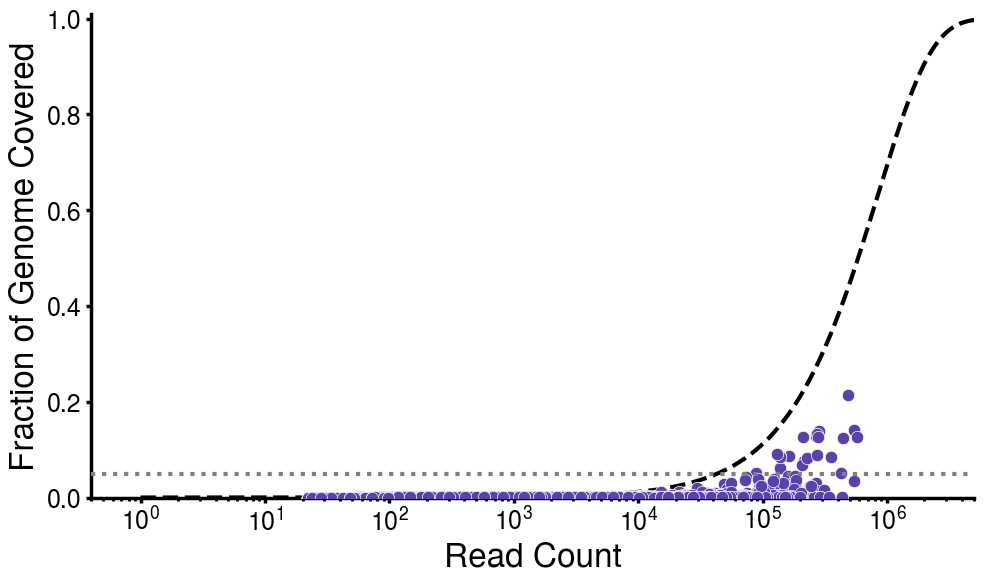

In [61]:
import numpy as np

read_length = 119
genome_size = 100_431_990

# log-spaced so the curve has resolution across the whole log axis
x_theory = np.logspace(0, 8, 1000)              # 1e3 -> 1e8 reads
coverage = (x_theory * read_length) / genome_size
y_theory = 1 - np.exp(-coverage)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(x_theory, y_theory, color="black", linewidth=3, linestyle="--",
        label="Lander-Waterman", zorder=2)

ax.axhline(0.05, color="gray", linewidth=3, linestyle=":", zorder=10)

ax.scatter(
    L4_exp5["total_reads"],
    L4_exp5["pct_1x"],
    color = colors[6],
    ec="white", linewidth=0.5, s=80, alpha=1, zorder=3,
)

ax.set_xlabel("Read Count", fontsize=24)
ax.set_ylabel("Fraction of Genome Covered", fontsize=24)
ax.tick_params(labelsize=18)
# ax.set_yscale("log")
ax.set_xscale("log")          # log x: read counts span decades
ax.set_xlim(0, 0.5e7)
ax.set_ylim(0, 1.01)             # linear y, fraction
# ax.legend(fontsize=18)

sns.despine()
plt.tight_layout()

In [75]:
L4_exp5['capsule'] = np.where(L4_exp5['pct_1x'] > 0.05, 'cell', 'background')
L4_exp5['capsule'] = L4_exp5['capsule'].astype('category')
L4_exp5

,total_reads,aligned_reads,pct_aligned,mean_read_length,mean_insert_size,read_duplicates,pct_duplicates,exonic_reads,exonic_enrichment,splice_reads,pct_1x,pct_5x,pct_10x,mean_coverage,median_coverage,gini,capsule
barcode,,,,,,,,,,,,,,,,,
A10_A7_A4_B2_20260531_L4_exp5_test,1734,1150,0.663206,119,314.8,104,0.180870,48,0.041739,8,0.000118,0.000028,0.000023,0.000838,0,0.999927,background
A10_A7_A5_A2_20260531_L4_exp5_test,40,28,0.700000,117,220.7,5,0.357143,0,0.000000,0,0.000014,0.000000,0.000000,0.000016,0,0.999933,background
A10_A7_A5_G1_20260531_L4_exp5_test,72,54,0.750000,117,200.5,5,0.185185,19,0.351852,0,0.000038,0.000000,0.000000,0.000042,0,0.999867,background
A10_A7_A6_A1_20260531_L4_exp5_test,146,112,0.767123,119,192.7,12,0.214286,73,0.651786,0,0.000057,0.000000,0.000000,0.000078,0,0.999903,background
A10_A7_A6_D2_20260531_L4_exp5_test,3212,452,0.140722,118,279.8,35,0.154867,260,0.575221,4,0.000188,0.000004,0.000000,0.000320,0,0.999710,background
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H12_H9_G5_A3_20260531_L4_exp5_test,2710,2232,0.823616,120,194.1,178,0.159498,1185,0.530914,9,0.000500,0.000117,0.000031,0.001659,0,0.999624,background
H12_H9_G6_D1_20260531_L4_exp5_test,6246,5020,0.803714,119,200.7,435,0.173307,2377,0.473506,20,0.000236,0.000090,0.000053,0.003679,0,0.999923,background
H12_H9_G6_H1_20260531_L4_exp5_test,48,22,0.458333,112,241.1,1,0.090909,6,0.272727,2,0.000020,0.000000,0.000000,0.000020,0,0.999889,background


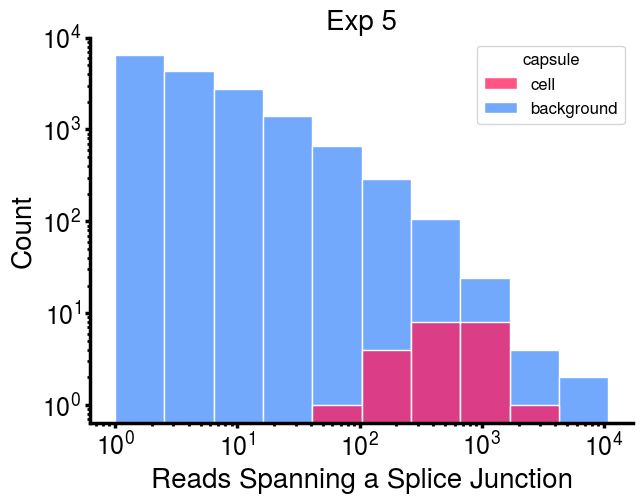

In [76]:
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)
sns.histplot(L4_exp5, x='splice_reads', 
             alpha=0.75,
             hue='capsule',
             hue_order=['cell', 'background'],
             palette={'background':colors[2], 'cell':colors[0]},
             # color = colors[2],
             linewidth=1,
             edgecolor='white',
             ax=ax,
             log_scale=True,
             bins=10
            )
ax.set_yscale('log')
plt.xlabel("Reads Spanning a Splice Junction", fontsize=20)
plt.ylabel("Count", fontsize=20)
plt.title('Exp 5', fontsize=20)
ax.tick_params(labelsize=18)

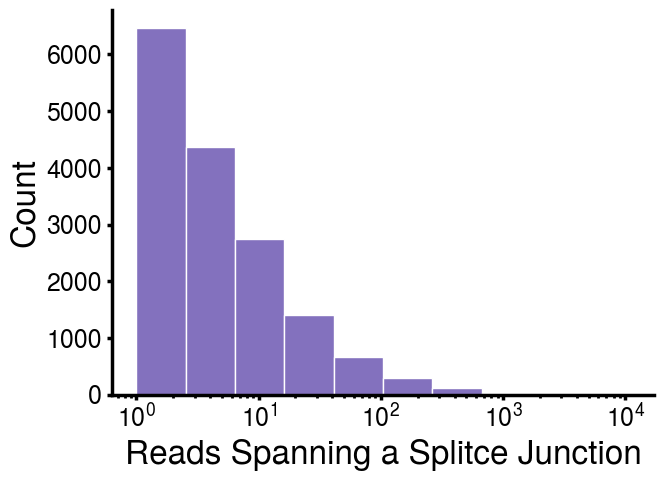

In [16]:
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)
sns.histplot(L4_exp5, x='pct_aligned', 
             alpha=0.75,
             color = colors[6],
             linewidth=1,
             edgecolor='white',
             ax=ax,
             # log_scale=True,
             bins=10
            )
# ax.set_yscale('log')
plt.xlabel("Reads Spanning a Splice Junction", fontsize=24)
plt.ylabel("Count", fontsize=24)
ax.tick_params(labelsize=18)

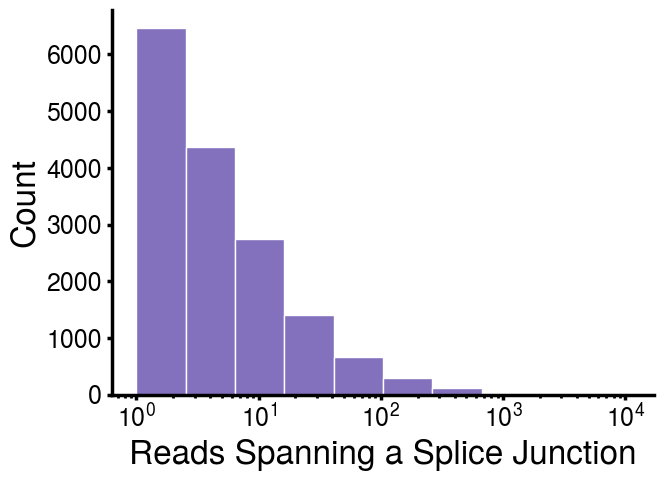

In [22]:
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)
sns.histplot(L4_exp5, x='splice_reads', 
             alpha=0.75,
             color = colors[6],
             linewidth=1,
             edgecolor='white',
             ax=ax,
             log_scale=True,
             bins=10
            )
# ax.set_yscale('log')
plt.xlabel("Reads Spanning a Splice Junction", fontsize=24)
plt.ylabel("Count", fontsize=24)
ax.tick_params(labelsize=18)

# Exp6

In [9]:
L4_exp6 = pd.read_csv('/fh/fast/srivatsan_s/grp/SrivatsanLab/Sanjay/00_SPC_paper/20260607_L4_exp6_test/my_align_run/results/260606_VH00738_415_AAJ7FY5M5/sc_qc_metrics.csv', index_col=0)
L4_exp6['experiment']='6'

,total_reads,aligned_reads,pct_aligned,mean_read_length,mean_insert_size,read_duplicates,pct_duplicates,exonic_reads,exonic_enrichment,splice_reads,pct_1x,pct_5x,pct_10x,mean_coverage,median_coverage,gini
barcode,,,,,,,,,,,,,,,,
A10_A7_A5_A2_20260606_worm_6_test,4202,20,0.004760,116,142.7,3,0.300000,15,0.750000,0,0.000010,0.000000,0.000000,0.000010,0,0.999909
A10_A7_A5_D2_20260606_worm_6_test,16798,7278,0.433266,117,224.6,667,0.183292,3157,0.433773,172,0.003219,0.000079,0.000017,0.004720,0,0.991559
A10_A7_B4_F2_20260606_worm_6_test,13082,7886,0.602813,117,279.8,695,0.176262,3591,0.455364,97,0.003977,0.000027,0.000001,0.005182,0,0.989163
A10_A7_D4_E1_20260606_worm_6_test,17280,8182,0.473495,117,176.1,782,0.191151,3533,0.431802,74,0.004084,0.000030,0.000005,0.005242,0,0.987999
A10_A7_D6_C1_20260606_worm_6_test,14328,8288,0.578448,116,181.9,770,0.185811,3813,0.460063,130,0.003914,0.000044,0.000007,0.005359,0,0.989378
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H12_H7_F6_D1_20260606_worm_6_test,16748,10130,0.604848,117,275.7,905,0.178677,4495,0.443731,275,0.004774,0.000059,0.000011,0.006595,0,0.988238
H12_H7_G5_H1_20260606_worm_6_test,3766,1710,0.454063,117,312.1,162,0.189474,734,0.429240,55,0.000820,0.000010,0.000005,0.001080,0,0.997045
H12_H8_A6_A2_20260606_worm_6_test,7600,3938,0.518158,116,278.9,351,0.178263,1888,0.479431,75,0.002029,0.000015,0.000005,0.002534,0,0.993138


/loc/scratch/52998854/ipykernel_4821/3421639995.py:30: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 0.5e7)


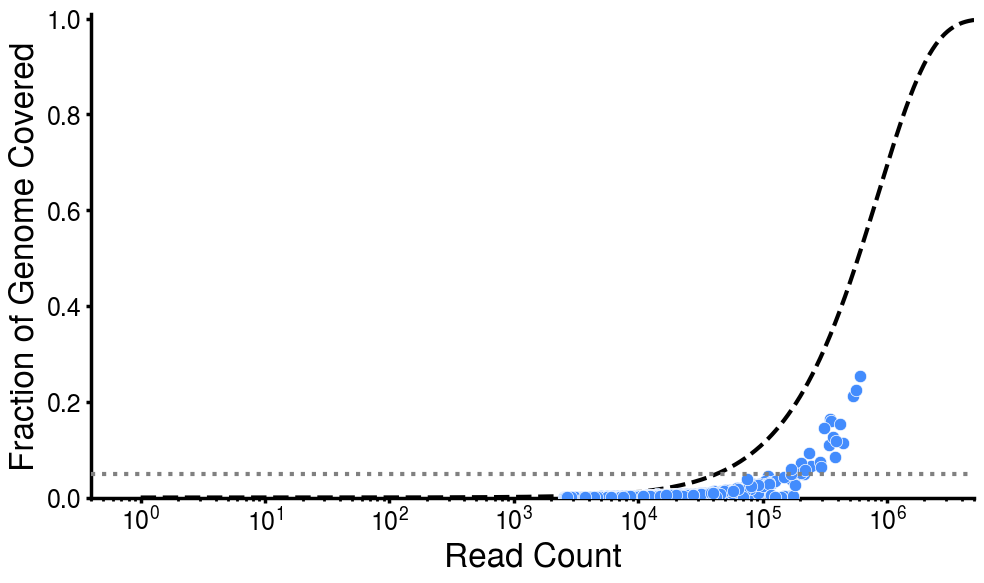

In [62]:
import numpy as np

read_length = 119
genome_size = 100_431_990

# log-spaced so the curve has resolution across the whole log axis
x_theory = np.logspace(0, 8, 1000)              # 1e3 -> 1e8 reads
coverage = (x_theory * read_length) / genome_size
y_theory = 1 - np.exp(-coverage)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(x_theory, y_theory, color="black", linewidth=3, linestyle="--",
        label="Lander-Waterman", zorder=2)

ax.axhline(0.05, color="gray", linewidth=3, linestyle=":", zorder=10)

ax.scatter(
    L4_exp6["total_reads"],
    L4_exp6["pct_1x"],
    color = colors[2],
    ec="white", linewidth=0.5, s=80, alpha=1, zorder=3,
)

ax.set_xlabel("Read Count", fontsize=24)
ax.set_ylabel("Fraction of Genome Covered", fontsize=24)
ax.tick_params(labelsize=18)
# ax.set_yscale("log")
ax.set_xscale("log")          # log x: read counts span decades
ax.set_xlim(0, 0.5e7)
ax.set_ylim(0, 1.01)             # linear y, fraction
# ax.legend(fontsize=18)

sns.despine()
plt.tight_layout()

In [66]:
L4_exp6['capsule'] = np.where(L4_exp6['pct_1x'] > 0.05, 'cell', 'background')
L4_exp6['capsule'] = L4_exp6['capsule'].astype('category')
L4_exp6

,total_reads,aligned_reads,pct_aligned,mean_read_length,mean_insert_size,read_duplicates,pct_duplicates,exonic_reads,exonic_enrichment,splice_reads,pct_1x,pct_5x,pct_10x,mean_coverage,median_coverage,gini,capsule
barcode,,,,,,,,,,,,,,,,,
A10_A7_A5_A2_20260606_worm_6_test,4202,20,0.004760,116,142.7,3,0.300000,15,0.750000,0,0.000010,0.000000,0.000000,0.000010,0,0.999909,background
A10_A7_A5_D2_20260606_worm_6_test,16798,7278,0.433266,117,224.6,667,0.183292,3157,0.433773,172,0.003219,0.000079,0.000017,0.004720,0,0.991559,background
A10_A7_B4_F2_20260606_worm_6_test,13082,7886,0.602813,117,279.8,695,0.176262,3591,0.455364,97,0.003977,0.000027,0.000001,0.005182,0,0.989163,background
A10_A7_D4_E1_20260606_worm_6_test,17280,8182,0.473495,117,176.1,782,0.191151,3533,0.431802,74,0.004084,0.000030,0.000005,0.005242,0,0.987999,background
A10_A7_D6_C1_20260606_worm_6_test,14328,8288,0.578448,116,181.9,770,0.185811,3813,0.460063,130,0.003914,0.000044,0.000007,0.005359,0,0.989378,background
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
H12_H7_F6_D1_20260606_worm_6_test,16748,10130,0.604848,117,275.7,905,0.178677,4495,0.443731,275,0.004774,0.000059,0.000011,0.006595,0,0.988238,background
H12_H7_G5_H1_20260606_worm_6_test,3766,1710,0.454063,117,312.1,162,0.189474,734,0.429240,55,0.000820,0.000010,0.000005,0.001080,0,0.997045,background
H12_H8_A6_A2_20260606_worm_6_test,7600,3938,0.518158,116,278.9,351,0.178263,1888,0.479431,75,0.002029,0.000015,0.000005,0.002534,0,0.993138,background


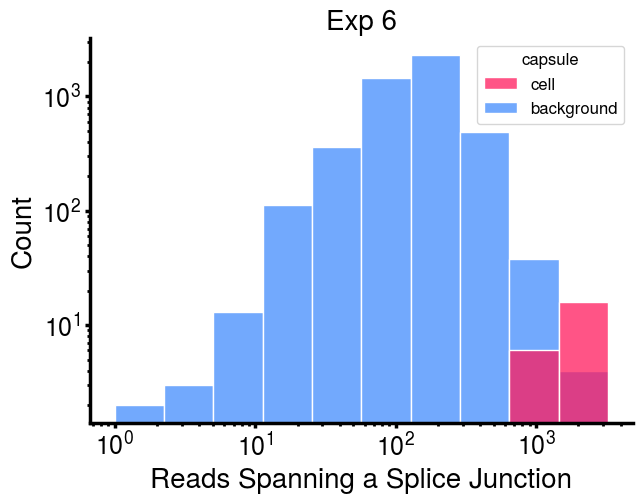

In [74]:
f, ax = plt.subplots(figsize=(7, 5))
sns.despine(f)
sns.histplot(L4_exp6, x='splice_reads', 
             alpha=0.75,
             hue='capsule',
             hue_order=['cell', 'background'],
             palette={'background':colors[2], 'cell':colors[0]},
             # color = colors[2],
             linewidth=1,
             edgecolor='white',
             ax=ax,
             log_scale=True,
             bins=10
            )
ax.set_yscale('log')
plt.xlabel("Reads Spanning a Splice Junction", fontsize=20)
plt.ylabel("Count", fontsize=20)
plt.title('Exp 6', fontsize=20)
ax.tick_params(labelsize=18)

# RNA Comparison

In [77]:
import scanpy as sc

### Spliced reads

In [79]:
worm_spliced = sc.read_h5ad('../../worm_debug/spliced_reads.h5ad')
worm_spliced

AnnData object with n_obs × n_vars = 9799 × 46748
    obs: 'experiment', 'class', 'capsule', 'total_reads', 'aligned_reads', 'unaligned_reads', 'pct_aligned', 'pct_unaligned', 'read_duplicates', 'pct_duplicates', 'exonic_reads', 'exonic_enrichment', 'splice_reads', 'pct_spliced_of_aligned', 'pct_1x', 'pct_5x', 'pct_10x', 'mean_coverage', 'median_coverage', 'gini', 'mean_read_length', 'mean_insert_size', 'aligned_dedup', 'splice_dedup', 'splice_dedup_frac', 'exonic_dedup', 'exonic_dedup_frac', 'intergenic_dedup', 'intergenic_dedup_frac', 'splice_count_total', 'n_genes_detected', 'exp_tag'
    var: 'gene_name', 'biotype', 'chrom', 'length'
    uns: 'counts_layer_description', 'genome', 'pipeline', 'subset', 'title'

In [80]:
sc.pp.calculate_qc_metrics(worm_spliced, inplace=True)

In [84]:
worm_spliced.obs.columns

Index(['experiment', 'class', 'capsule', 'total_reads', 'aligned_reads',
       'unaligned_reads', 'pct_aligned', 'pct_unaligned', 'read_duplicates',
       'pct_duplicates', 'exonic_reads', 'exonic_enrichment', 'splice_reads',
       'pct_spliced_of_aligned', 'pct_1x', 'pct_5x', 'pct_10x',
       'mean_coverage', 'median_coverage', 'gini', 'mean_read_length',
       'mean_insert_size', 'aligned_dedup', 'splice_dedup',
       'splice_dedup_frac', 'exonic_dedup', 'exonic_dedup_frac',
       'intergenic_dedup', 'intergenic_dedup_frac', 'splice_count_total',
       'n_genes_detected', 'exp_tag', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'],
      dtype='object')

<Axes: xlabel='exp_tag', ylabel='n_genes_detected'>

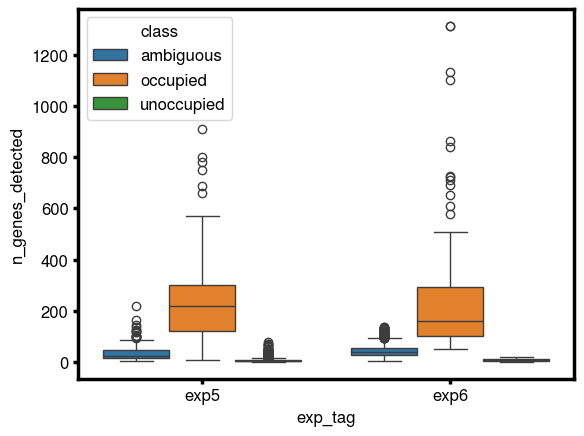

In [85]:
sns.boxplot(worm_spliced.obs, x='exp_tag', y='n_genes_detected', hue='class')

In [86]:
# Saving count data
worm_spliced.layers["counts"] = worm_spliced.X.copy()

In [87]:
# Normalizing to median total counts
sc.pp.normalize_total(worm_spliced)
# Logarithmize the data
sc.pp.log1p(worm_spliced)

/home/dmullane/micromamba/envs/default_jupyter/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: Some cells have zero counts
  return fn(*args_all, **kw)


In [89]:
sc.pp.highly_variable_genes(worm_spliced, n_top_genes=250)

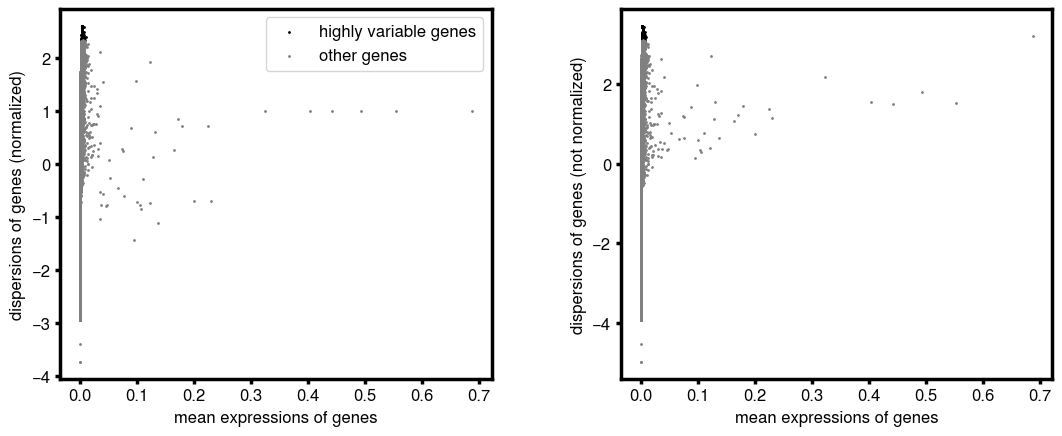

In [90]:
sc.pl.highly_variable_genes(worm_spliced)

In [97]:
sc.tl.pca(worm_spliced, use_highly_variable=False)

/home/dmullane/micromamba/envs/default_jupyter/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


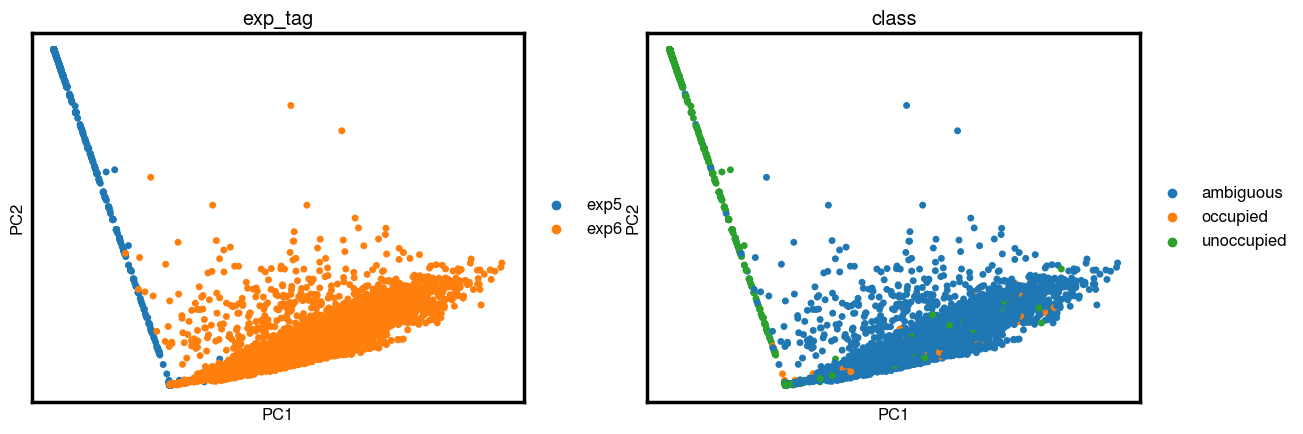

In [105]:
sc.pl.pca(
    # worm_spliced[worm_spliced.obs['exp_tag']=='exp5'],
    worm_spliced,
    color=["exp_tag", "class",],
    s=100,
    
    # dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    # ncols=2,
    # size=2,
)

### All exonic reads- only occupied capsules

In [106]:
worm_exonic = sc.read_h5ad('../../worm_debug/occupied_cells.h5ad')
worm_exonic

AnnData object with n_obs × n_vars = 44 × 46748
    obs: 'experiment', 'class', 'capsule', 'total_reads', 'aligned_reads', 'unaligned_reads', 'pct_aligned', 'pct_unaligned', 'read_duplicates', 'pct_duplicates', 'exonic_reads', 'exonic_enrichment', 'splice_reads', 'pct_spliced_of_aligned', 'pct_1x', 'pct_5x', 'pct_10x', 'mean_coverage', 'median_coverage', 'gini', 'mean_read_length', 'mean_insert_size', 'aligned_dedup', 'splice_dedup', 'splice_dedup_frac', 'exonic_dedup', 'exonic_dedup_frac', 'intergenic_dedup', 'intergenic_dedup_frac', 'exonic_count_total_h5ad', 'splice_count_total_h5ad', 'n_genes_detected_exonic', 'n_genes_detected_splice', 'exp_tag'
    var: 'gene_name', 'biotype', 'chrom', 'length'
    uns: 'X_description', 'genome', 'layer_splice_description', 'subset', 'title'
    layers: 'splice'

In [107]:
sc.pp.calculate_qc_metrics(worm_exonic, inplace=True)

In [134]:
worm_exonic

AnnData object with n_obs × n_vars = 44 × 46748
    obs: 'experiment', 'class', 'capsule', 'total_reads', 'aligned_reads', 'unaligned_reads', 'pct_aligned', 'pct_unaligned', 'read_duplicates', 'pct_duplicates', 'exonic_reads', 'exonic_enrichment', 'splice_reads', 'pct_spliced_of_aligned', 'pct_1x', 'pct_5x', 'pct_10x', 'mean_coverage', 'median_coverage', 'gini', 'mean_read_length', 'mean_insert_size', 'aligned_dedup', 'splice_dedup', 'splice_dedup_frac', 'exonic_dedup', 'exonic_dedup_frac', 'intergenic_dedup', 'intergenic_dedup_frac', 'exonic_count_total_h5ad', 'splice_count_total_h5ad', 'n_genes_detected_exonic', 'n_genes_detected_splice', 'exp_tag', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'gene_name', 'biotype', 'chrom', 'length', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts'

<Axes: xlabel='exp_tag', ylabel='n_genes_by_counts'>

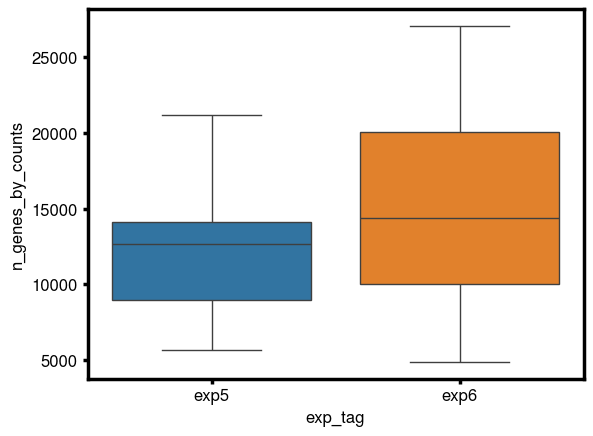

In [112]:
sns.boxplot(worm_exonic.obs, x='exp_tag', y='n_genes_by_counts', hue='exp_tag')

<Axes: xlabel='exp_tag', ylabel='total_counts'>

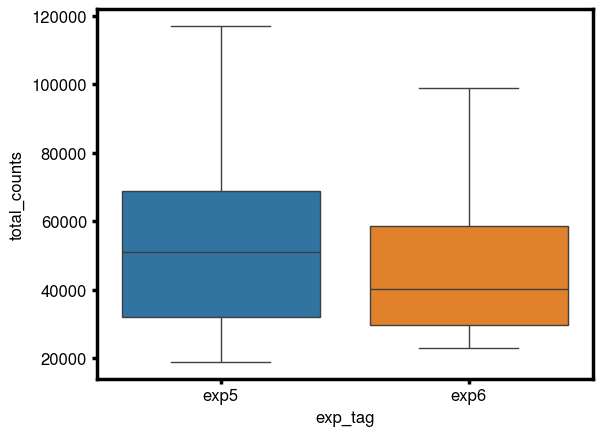

In [135]:
sns.boxplot(worm_exonic.obs, x='exp_tag', y='total_counts', hue='exp_tag')

In [114]:
# Saving count data
worm_exonic.layers["counts"] = worm_exonic.X.copy()

In [115]:
# Normalizing to median total counts
sc.pp.normalize_total(worm_exonic)
# Logarithmize the data
sc.pp.log1p(worm_exonic)

In [123]:
sc.pp.highly_variable_genes(worm_exonic, n_top_genes=1000)

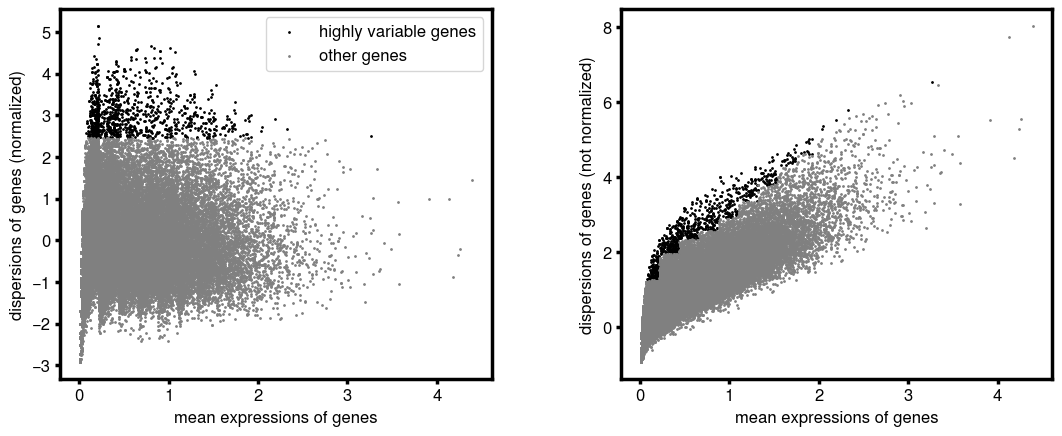

In [124]:
sc.pl.highly_variable_genes(worm_exonic)

In [125]:
sc.tl.pca(worm_exonic, use_highly_variable=True)

/home/dmullane/micromamba/envs/default_jupyter/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


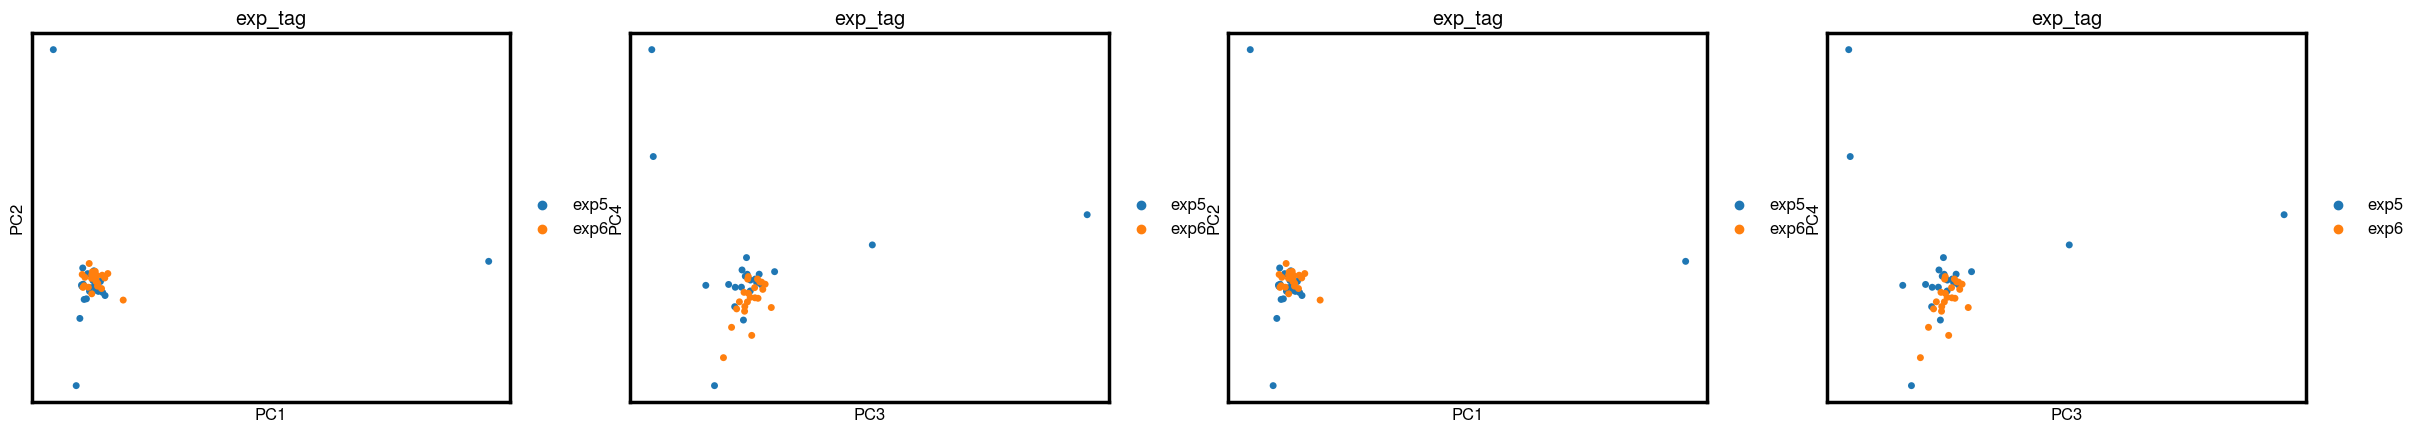

In [127]:
sc.pl.pca(
    # worm_spliced[worm_spliced.obs['exp_tag']=='exp5'],
    worm_exonic,
    color=["exp_tag"],
    s=100,
    
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    # ncols=2,
    # size=2,
)

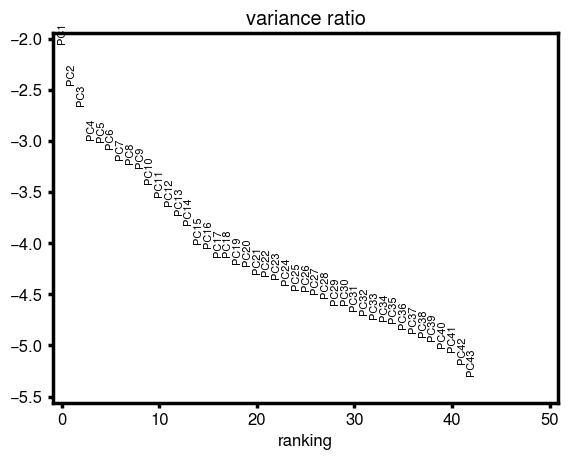

In [128]:
sc.pl.pca_variance_ratio(worm_exonic, n_pcs=50, log=True)

In [130]:
sc.pp.neighbors(worm_exonic)
sc.tl.umap(worm_exonic)

/home/dmullane/micromamba/envs/default_jupyter/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


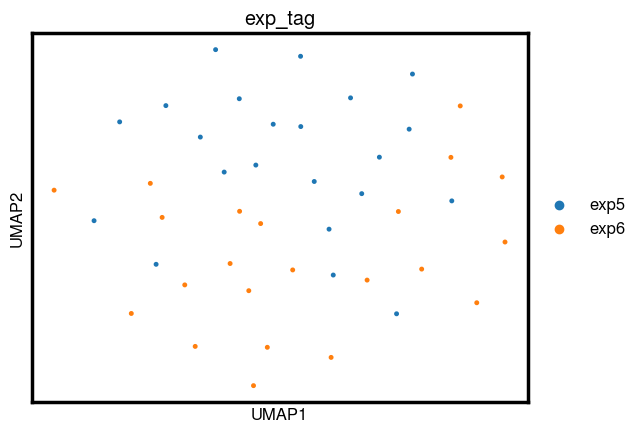

In [133]:
sc.pl.umap(
    worm_exonic,
    color="exp_tag",
    size=50
)